# Analiza i predykcja trudności złapania Pokémonów w Pokémon GO

Pokémon GO to gra mobilna oparta na lokalizacji gracza. Jednym z podstawowych elementów rozgrywki jest spotykanie Pokémonów na mapie i próba ich złapania poprzez rzucenie Poké Ballem.

Nie każdy Pokémon jest tak samo łatwy do złapania. Gra przypisuje gatunkom różne parametry, m.in. bazową szansę złapania oraz szansę ucieczki po nieudanej próbie. Dzięki temu dane z gry można wykorzystać do analizy czynników wpływających na trudność złapania Pokémona.

### Cel projektu

Celem projektu jest stworzenie modelu klasyfikacyjnego przewidującego, czy Pokémon w Pokémon GO jest relatywnie łatwy czy trudny do złapania.

Zmienna celu zostanie utworzona na podstawie dwóch cech opisujących mechanikę łapania: `Capture_rate` oraz `Escape_rate`. Na ich podstawie obliczone zostanie uproszczone prawdopodobieństwo ostatecznego złapania Pokémona przed jego ucieczką.

### Import bibliotek, wczytanie i podgląd danych

Dane wykorzystane w projekcie pochodzą ze zbioru **Pokémon GO Dataset: 1–5 Generations** dostępnego w serwisie Kaggle:

https://www.kaggle.com/datasets/netzuel/pokmon-go-dataset-15-generations/data

Zbiór zawiera bazowe informacje o Pokémonach w Pokémon GO, m.in. statystyki `Attack`, `Defense`, `Stamina`, typy Pokémonów, `MaxCP`, `Capture_rate` oraz `Escape_rate`.


W pierwszym kroku importowane są biblioteki potrzebne do analizy danych, wizualizacji oraz późniejszego przygotowania modeli klasyfikacyjnych.

In [1]:
# Podstawowe biblioteki
import numpy as np
import pandas as pd

# Wizualizacja danych
import matplotlib.pyplot as plt
import seaborn as sns

# Przygotowanie danych i walidacja
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    validation_curve,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modele klasyfikacyjne
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Metryki i ocena modeli
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv('pogo.csv')
df.head()

,Name,Pokedex,Stamina,Attack,Defense,Primary,Secondary,MaxHP,Capture_rate,Escape_rate,Weight,Height,Legendary,MaxCP,Generation
0,Bulbasaur,1,128,118,111,Grass,Poison,113,0.20,0.10,6.9,0.7,No,1115,1
1,Ivysaur,2,155,151,143,Grass,Poison,134,0.10,0.07,13.0,1.0,No,1699,1
2,Venusaur,3,190,198,189,Grass,Poison,162,0.05,0.05,100.0,2.0,No,2720,1
3,Charmander,4,118,116,93,Fire,NaN,105,0.20,0.10,8.5,0.6,No,980,1
4,Charmeleon,5,151,158,126,Fire,NaN,131,0.10,0.07,19.0,1.1,No,1653,1


Pierwsze wiersze zbioru pozwalają sprawdzić strukturę danych, nazwy kolumn oraz przykładowe wartości cech.

### Podstawowe informacje o danych

Zbiór danych zawiera następujące kolumny z informacjami o Pokémonach dostępnych w Pokémon GO:

- `Name` — nazwa Pokémona.
- `Pokedex` — numer Pokémona w Pokédexie. Jest to identyfikator porządkowy, a nie cecha opisująca właściwości Pokémona.
- `Stamina` — bazowa wytrzymałość Pokémona.
- `Attack` — bazowa siła ataku Pokémona.
- `Defense` — bazowa wartość obrony Pokémona.
- `Primary` — główny typ Pokémona, np. Water, Fire, Grass.
- `Secondary` — drugi typ Pokémona. Brak wartości oznacza, że Pokémon ma tylko jeden typ.
- `MaxHP` — maksymalna liczba punktów życia.
- `Capture_rate` — bazowe prawdopodobieństwo złapania Pokémona w jednej próbie. Im niższa wartość tego parametru, tym trudniej złapać Pokémona. Wartość ta nie oznacza całkowitej szansy złapania w całym spotkaniu, ponieważ po nieudanej próbie Pokémon może pozostać i umożliwić kolejne rzuty.
- `Escape_rate` — prawdopodobieństwo ucieczki Pokémona po nieudanej próbie złapania, czyli po wydostaniu się z Poké Balla. Im wyższa wartość tego parametru, tym większa szansa, że Pokémon ucieknie po nieudanym rzucie. W innych źródłach parametr ten bywa nazywany `Flee_rate`.
- `Weight` — masa Pokémona.
- `Height` — wzrost Pokémona.
- `Legendary` — informacja, czy Pokémon jest legendarny.
- `MaxCP` — maksymalna wartość Combat Power, czyli ogólnego wskaźnika siły Pokémona w grze.
- `Generation` — generacja, z której pochodzi Pokémon.

W kontekście trudności złapania kluczowe są więc dwie zależności: niższy `Capture_rate` oznacza trudniejsze złapanie w pojedynczej próbie, a wyższy `Escape_rate` zwiększa ryzyko zakończenia spotkania po nieudanym rzucie.

In [3]:
print('Rozmiar danych: ', df.shape)

Rozmiar danych:  (649, 15)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          649 non-null    object 
 1   Pokedex       649 non-null    int64  
 2   Stamina       649 non-null    int64  
 3   Attack        649 non-null    int64  
 4   Defense       649 non-null    int64  
 5   Primary       649 non-null    object 
 6   Secondary     309 non-null    object 
 7   MaxHP         649 non-null    int64  
 8   Capture_rate  649 non-null    float64
 9   Escape_rate   649 non-null    float64
 10  Weight        649 non-null    float64
 11  Height        649 non-null    float64
 12  Legendary     649 non-null    object 
 13  MaxCP         649 non-null    int64  
 14  Generation    649 non-null    int64  
dtypes: float64(4), int64(7), object(4)
memory usage: 76.2+ KB


In [5]:
df.describe()

,Pokedex,Stamina,Attack,Defense,MaxHP,Capture_rate,Escape_rate,Weight,Height,MaxCP,Generation
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,325.000000,168.867488,161.147920,140.755008,144.845917,0.242681,0.083667,57.493374,1.148752,1918.006163,3.052388
std,187.494444,45.582184,56.516956,49.433364,35.959609,0.173709,0.055451,90.558634,1.036839,901.856030,1.494960
min,1.000000,1.000000,17.000000,32.000000,12.000000,0.000000,0.000000,0.100000,0.100000,274.000000,1.000000
25%,163.000000,137.000000,118.000000,100.000000,120.000000,0.100000,0.060000,10.100000,0.600000,1144.000000,2.000000
50%,325.000000,163.000000,159.000000,137.000000,140.000000,0.200000,0.070000,29.000000,1.000000,1859.000000,3.000000
75%,487.000000,190.000000,204.000000,175.000000,162.000000,0.300000,0.100000,61.000000,1.400000,2564.000000,4.000000
max,649.000000,496.000000,345.000000,396.000000,403.000000,1.000000,0.990000,950.000000,14.500000,4431.000000,5.000000


In [6]:
df.describe(include="object")

,Name,Primary,Secondary,Legendary
count,649,649,309,649
unique,649,18,17,2
top,Genesect,Water,Flying,No
freq,1,100,81,610


Podstawowy opis danych pozwala sprawdzić liczbę obserwacji, typy zmiennych, zakresy wartości oraz potencjalne braki danych. Jest to potrzebne przed dalszą analizą, ponieważ część kolumn ma charakter liczbowy, a część kategoryczny.

### Czyszczenie, rozkłady zmiennych i korekta danych

In [7]:
print("Pełne duplikaty:", df.duplicated().sum())
print("Duplikaty nazw:", df["Name"].duplicated().sum())

Pełne duplikaty: 0
Duplikaty nazw: 0


Sprawdzenie duplikatów pozwala upewnić się, że ten sam Pokémon nie został przypadkowo zapisany kilka razy. Osobno sprawdzane są pełne duplikaty wierszy oraz powtórzenia nazw Pokémonów.

In [8]:
print('Braki danych:', df.isna().sum())

Braki danych: Name              0
Pokedex           0
Stamina           0
Attack            0
Defense           0
Primary           0
Secondary       340
MaxHP             0
Capture_rate      0
Escape_rate       0
Weight            0
Height            0
Legendary         0
MaxCP             0
Generation        0
dtype: int64


Braki w kolumnie `Secondary` nie są traktowane jako błąd danych. Oznaczają one, że dany Pokémon ma tylko jeden typ. Z tego powodu kolumna nie wymaga uzupełniania na tym etapie.

Na początku analizowane są rozkłady zmiennych liczbowych. Pozwala to zauważyć wartości skrajne, asymetrię rozkładów oraz ogólną skalę poszczególnych cech.

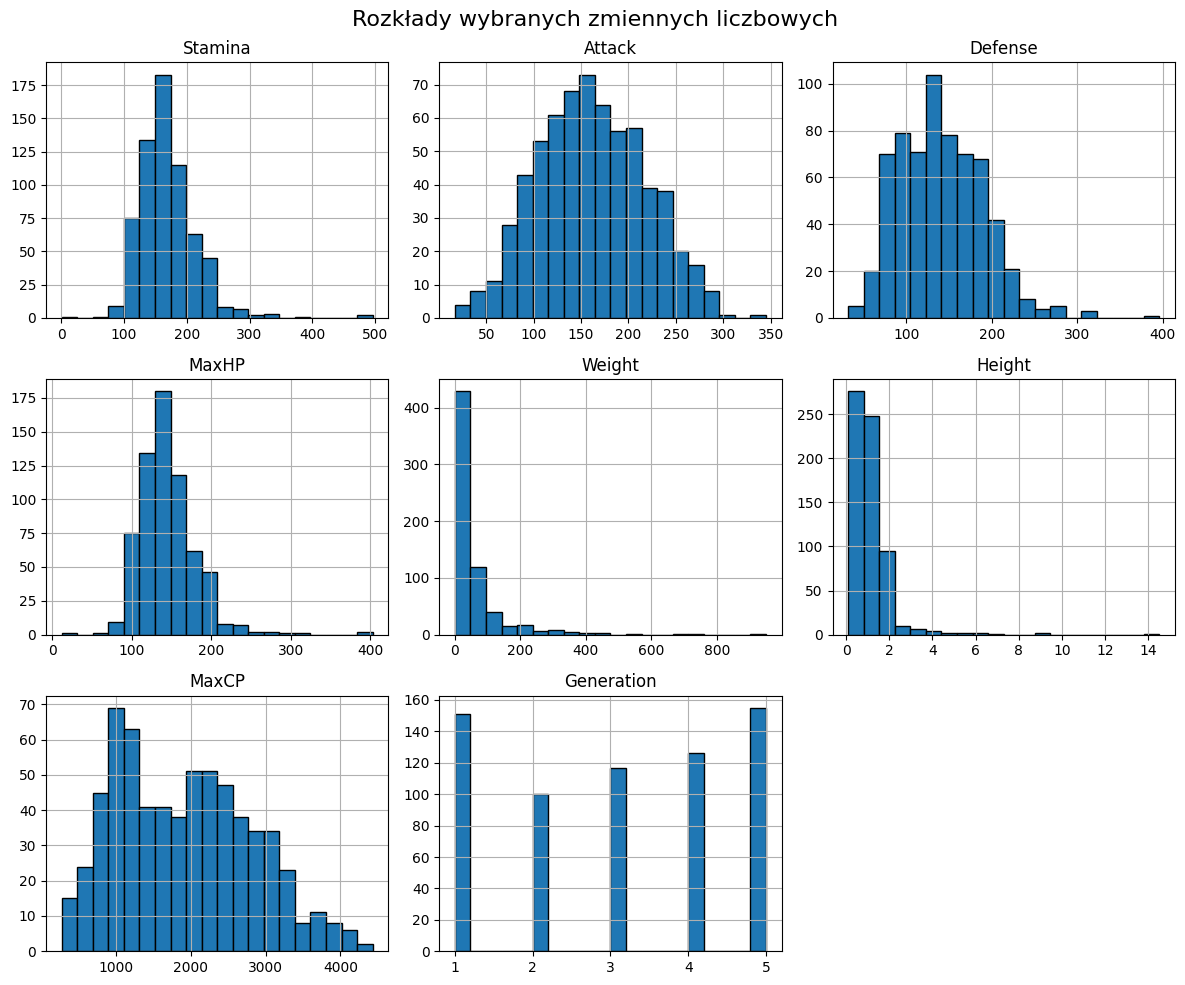

In [9]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

numeric_cols = numeric_cols.drop(["Pokedex", "Capture_rate", "Escape_rate"])

df[numeric_cols].hist(figsize=(12, 10), bins=20, edgecolor="black")

plt.suptitle("Rozkłady wybranych zmiennych liczbowych", fontsize=16)
plt.tight_layout()
plt.show()

Szczególnie istotną cechą jest `Capture_rate`, ponieważ opisuje bazową łatwość złapania Pokémona w pojedynczej próbie. Rozkład tej zmiennej pozwala sprawdzić, czy większość Pokémonów ma podobną szansę złapania, czy występują wyraźne grupy łatwiejsze i trudniejsze.

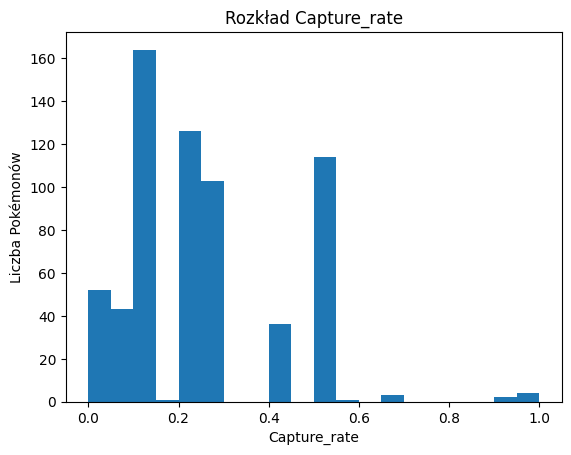

In [10]:
plt.hist(df['Capture_rate'], bins=20)
plt.title('Rozkład Capture_rate')
plt.xlabel("Capture_rate")
plt.ylabel("Liczba Pokémonów")
plt.show()

In [11]:
df['Capture_rate'].max()

1.0

In [12]:
df[df['Capture_rate']==1]

,Name,Pokedex,Stamina,Attack,Defense,Primary,Secondary,MaxHP,Capture_rate,Escape_rate,Weight,Height,Legendary,MaxCP,Generation
150,Mew,151,225,210,210,Psychic,NaN,189,1.0,0.0,4.0,0.40,Sí,3265,1
250,Celebi,251,225,210,210,Psychic,Grass,189,1.0,0.0,5.0,0.61,No,3265,2
384,Jirachi,385,225,210,210,Steel,Psychic,189,1.0,0.0,1.1,0.30,Sí,3265,4
493,Victini,494,225,210,210,Psychic,Fire,189,1.0,0.1,4.0,0.40,Sí,3265,4


W danych występują cztery Pokémony z `Capture_rate = 1.0`: Mew, Celebi, Jirachi i Victini. Nie potraktowano ich jako błędów danych, ponieważ są to Pokémony specjalne lub mityczne, dla których w grze występuje niestandardowa mechanika łapania. Wartość `1.0` oznacza maksymalną bazową wartość współczynnika złapania.

In [13]:
df[df["Capture_rate"] == 0][["Name", "Capture_rate", "Escape_rate"]]

,Name,Capture_rate,Escape_rate
171,Pichu,0.0,0.05
172,Cleffa,0.0,0.05
173,Igglybuff,0.0,0.05
174,Togepi,0.0,0.05
235,Tyrogue,0.0,0.20
237,Smoochum,0.0,0.20
238,Elekid,0.0,0.20
239,Magby,0.0,0.20
446,Riolu,0.0,0.20


W zbiorze danych część Pokémonów miała wartość `Capture_rate = 0`. Dotyczyło to głównie tzw. baby Pokémonów, dla których mechanika łapania nie została poprawnie opisana w pierwotnym zbiorze.

Wartość `0` nie została potraktowana jako rzeczywiste prawdopodobieństwo złapania w standardowym spotkaniu, lecz jako wartość nieadekwatna dla analizowanego scenariusza. Dlatego wartości te zostały ręcznie uzupełnione na podstawie zewnętrznych źródeł z aktualnymi informacjami o bazowych współczynnikach łapania w Pokémon GO.

In [14]:
capture_rate_updates = {
    "Pichu": 0.25,
    "Cleffa": 0.25,
    "Igglybuff": 0.25,
    "Togepi": 0.25,
    "Tyrogue": 0.25,
    "Smoochum": 0.25,
    "Elekid": 0.25,
    "Magby": 0.25,
    "Riolu": 0.25
}

df.loc[df["Name"].isin(capture_rate_updates.keys()), "Capture_rate"] = (
    df["Name"].map(capture_rate_updates)
)

In [15]:
df[df["Name"].isin(capture_rate_updates.keys())][["Name", "Capture_rate"]]

,Name,Capture_rate
171,Pichu,0.25
172,Cleffa,0.25
173,Igglybuff,0.25
174,Togepi,0.25
235,Tyrogue,0.25
237,Smoochum,0.25
238,Elekid,0.25
239,Magby,0.25
446,Riolu,0.25


Po korekcie wartości zerowych ponownie analizowany jest rozkład `Capture_rate`, aby upewnić się, że zmienna może zostać wykorzystana do dalszego tworzenia zmiennej celu.

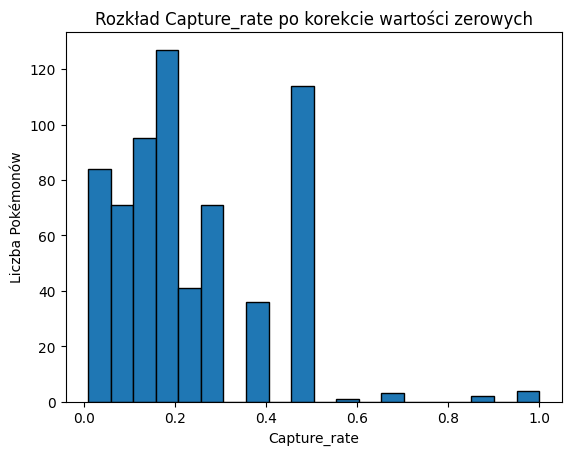

In [16]:
plt.hist(df["Capture_rate"], bins=20, edgecolor="black")
plt.title("Rozkład Capture_rate po korekcie wartości zerowych")
plt.xlabel("Capture_rate")
plt.ylabel("Liczba Pokémonów")
plt.show()

Drugą ważną cechą jest `Escape_rate`, czyli szansa ucieczki po nieudanej próbie złapania. Parametr ten nie jest przeciwieństwem `Capture_rate`, lecz opisuje kolejny etap mechaniki łapania.

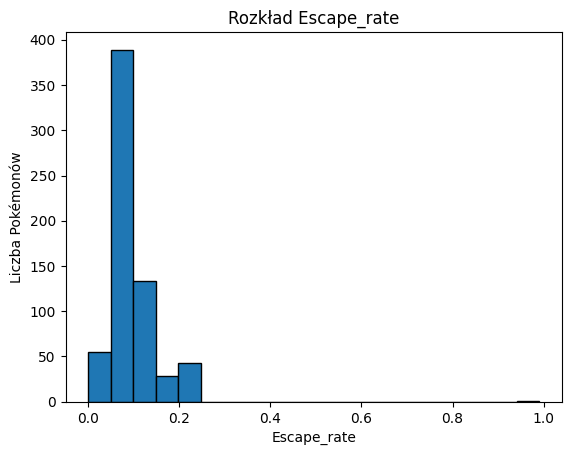

In [17]:
plt.hist(df['Escape_rate'], bins=20, edgecolor="black")
plt.title('Rozkład Escape_rate')
plt.xlabel("Escape_rate")
plt.ylabel("Liczba Pokémonów")
plt.show()

In [18]:
df['Escape_rate'].max()

0.99

In [19]:
df[df['Escape_rate']==df['Escape_rate'].max()]

,Name,Pokedex,Stamina,Attack,Defense,Primary,Secondary,MaxHP,Capture_rate,Escape_rate,Weight,Height,Legendary,MaxCP,Generation
62,Abra,63,93,195,82,Psychic,NaN,85,0.5,0.99,19.5,0.9,No,1342,1


Na wykresie rozkładu `Escape_rate` widoczna jest pojedyncza bardzo wysoka wartość równa `0.99`. Dotyczy ona Pokémona Abra. Nie potraktowano jej jednak jako błędu ani typowej wartości odstającej do usunięcia, ponieważ Abra jest szczególnym przypadkiem w mechanice gry - Pokémon ten jest znany z bardzo wysokiej szansy ucieczki po nieudanej próbie złapania.

Z tego powodu wartość `Escape_rate = 0.99` pozostawiono w zbiorze danych. Reprezentuje ona rzeczywistą specyfikę tego gatunku, a nie przypadkową pomyłkę w danych.

### Analiza korelacji

W tej części sprawdzane są zależności między wybranymi cechami liczbowymi. Korelacja pomaga wstępnie ocenić, które zmienne mogą być powiązane z mechaniką łapania Pokémonów.

In [20]:
# kolumna 0/1 dla "Legendary"
df["Legendary"] = df["Legendary"].map({
    "Sí": 1,
    "No": 0
})

# wyrzucamy kolumny object
df_corr = df.drop(columns=["Name", "Primary", "Secondary"])

df_corr

,Pokedex,Stamina,Attack,Defense,MaxHP,Capture_rate,Escape_rate,Weight,Height,Legendary,MaxCP,Generation
0,1,128,118,111,113,0.20,0.10,6.9,0.7,0,1115,1
1,2,155,151,143,134,0.10,0.07,13.0,1.0,0,1699,1
2,3,190,198,189,162,0.05,0.05,100.0,2.0,0,2720,1
3,4,118,116,93,105,0.20,0.10,8.5,0.6,0,980,1
4,5,151,158,126,131,0.10,0.07,19.0,1.1,0,1653,1
...,...,...,...,...,...,...,...,...,...,...,...,...
644,645,205,261,182,173,0.02,0.01,68.0,1.5,1,3588,5
645,646,245,246,170,205,0.02,0.01,325.0,3.0,1,3575,5
646,647,209,260,192,177,0.02,0.01,48.5,1.4,0,3698,5
647,648,225,250,225,189,0.02,0.01,6.5,0.6,0,3972,5


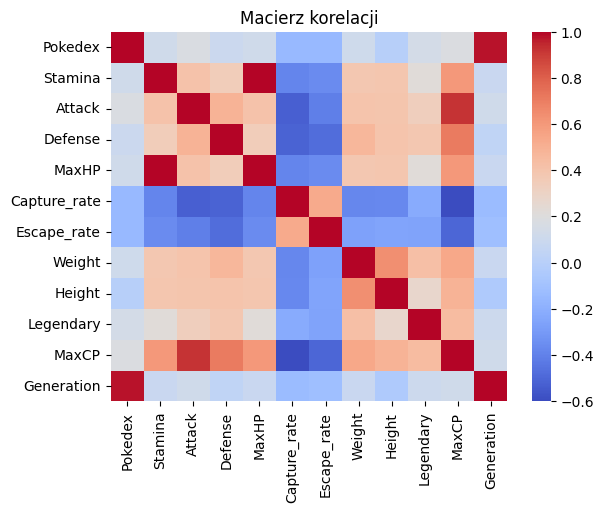

In [21]:
sns.heatmap(df_corr.corr(), cmap="coolwarm")
plt.title('Macierz korelacji')
plt.show()

Macierz korelacji pokazuje, że część cech opisujących siłę Pokémona, takich jak `Attack`, `Defense`, `Stamina`, `MaxHP` i `MaxCP`, jest ze sobą silnie powiązana. Jest to oczekiwane, ponieważ opisują one ogólną siłę i wytrzymałość Pokémona.

Ponieważ `Capture_rate` i `Escape_rate` opisują dwa kolejne etapy mechaniki łapania, warto osobno sprawdzić zależność między tymi zmiennymi. `Capture_rate` dotyczy szansy złapania w danej próbie, natomiast `Escape_rate` ma znaczenie dopiero wtedy, gdy Pokémon wydostanie się z Poké Balla.

In [22]:
df["Capture_rate"].corr(df["Escape_rate"])

np.float64(0.5246734177695593)

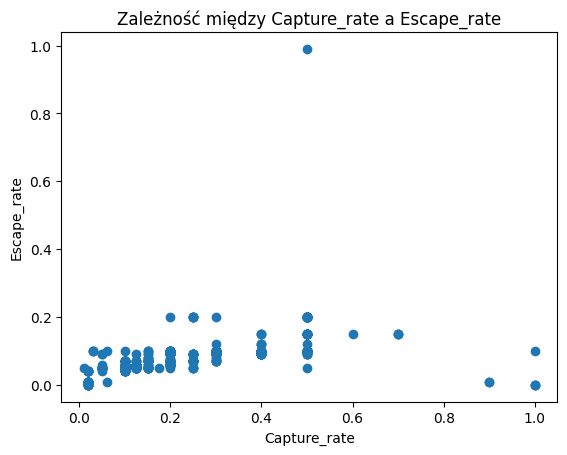

In [23]:
plt.scatter(df['Capture_rate'],df['Escape_rate'])
plt.title("Zależność między Capture_rate a Escape_rate")
plt.xlabel("Capture_rate")
plt.ylabel("Escape_rate")
plt.show()

Mimo stosunkowo wysokiej korelacji między Capture_rate i Escape_rate, wykres punktowy nie pokazuje wyraźnej liniowej zależności. Wynika to z dyskretnego charakteru zmiennych, nakładania się punktów oraz obecności obserwacji odstającej z bardzo wysokim Escape_rate. Po usunięciu outliera zależność powinna zostać oceniona ponownie.

In [24]:
df_no_outlier = df[df["Escape_rate"] < 0.9]

df_no_outlier["Capture_rate"].corr(df_no_outlier["Escape_rate"])

np.float64(0.6369805351092002)

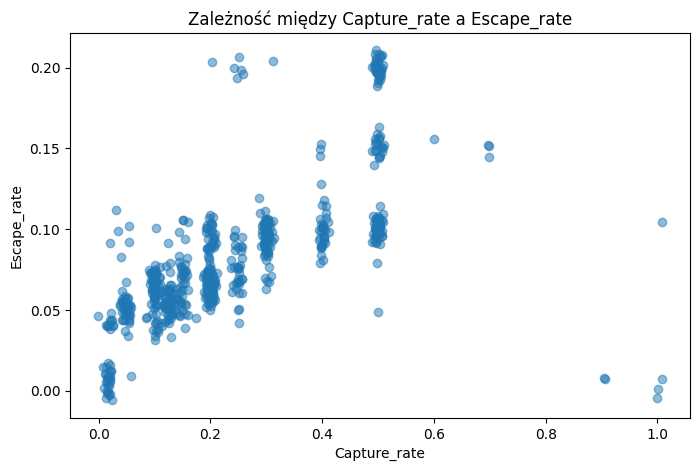

In [25]:
n = len(df_no_outlier)

x = df_no_outlier["Capture_rate"] + np.random.normal(0, 0.005, size=n)
y = df_no_outlier["Escape_rate"] + np.random.normal(0, 0.005, size=n)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.5)

plt.title("Zależność między Capture_rate a Escape_rate")
plt.xlabel("Capture_rate")
plt.ylabel("Escape_rate")

plt.show()

Po usunięciu obserwacji odstającej oraz dodaniu lekkiego przesunięcia punktów widoczna jest dodatnia zależność między `Capture_rate` i `Escape_rate`. Oznacza to, że Pokémony łatwiejsze do złapania często mają również większą skłonność do ucieczki po nieudanej próbie. Może to sugerować częściowe równoważenie się mechanik łapania i ucieczki.

Kolumny `Primary` i `Secondary` są zmiennymi kategorycznymi, dlatego przed analizą korelacji zostały zakodowane metodą one-hot encoding. Dzięki temu można sprawdzić, czy przynależność do określonego typu jest powiązana z `Capture_rate` lub `Escape_rate`.

In [26]:
df_type_encoded = df[["Primary", "Secondary"]].copy()

df_type_encoded = pd.get_dummies(
    df_type_encoded,
    drop_first=False
)

# dodanie zakodowanych kolumn Primary i Secondary
df = pd.concat([df, df_type_encoded], axis=1)

df_type_encoded.shape

(649, 35)

Poniżej pokazano typy Pokémonów o najwyższej bezwzględnej korelacji z `Capture_rate` oraz `Escape_rate`.

In [27]:
df_type_encoded["Capture_rate"] = df["Capture_rate"]
df_type_encoded["Escape_rate"] = df["Escape_rate"]

corr_table = df_type_encoded.corr()[["Capture_rate", "Escape_rate"]]
corr_table = corr_table.drop(index=["Capture_rate", "Escape_rate"])

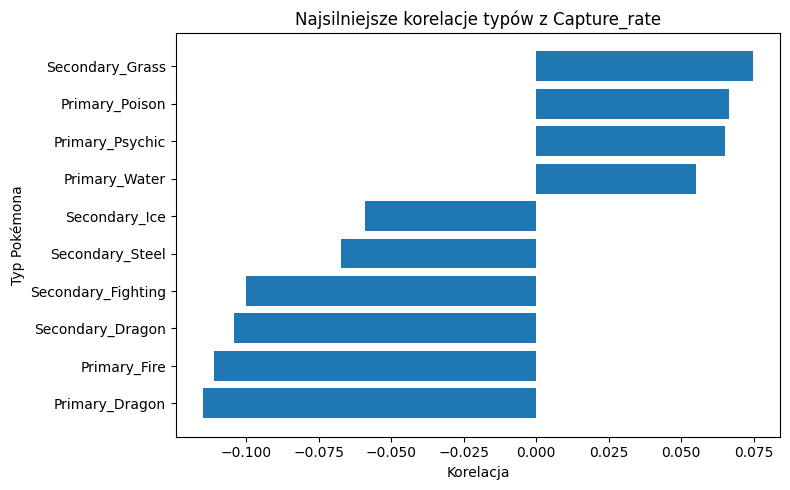

In [28]:
corr_capture = corr_table["Capture_rate"].copy()

top_corr_capture = (
    corr_capture
    .reindex(corr_capture.abs().sort_values(ascending=False).index)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(8, 5))

plt.barh(top_corr_capture.index, top_corr_capture.values)

plt.title("Najsilniejsze korelacje typów z Capture_rate")
plt.xlabel("Korelacja")
plt.ylabel("Typ Pokémona")

plt.tight_layout()
plt.show()

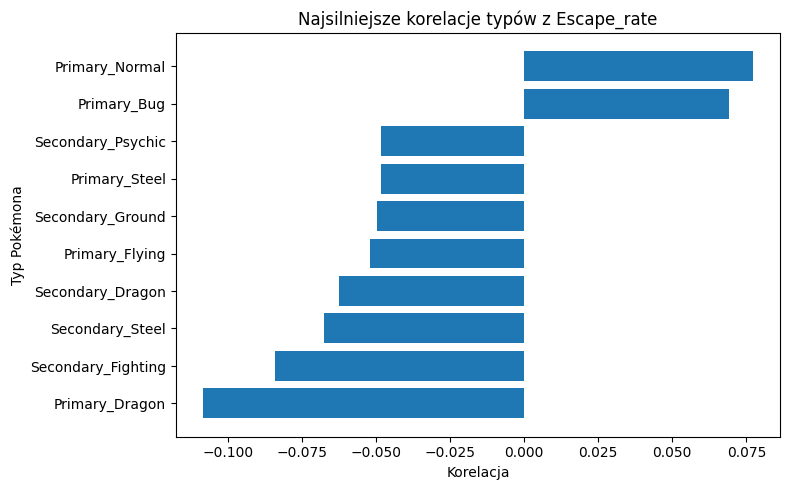

In [29]:
corr_escape = corr_table["Escape_rate"].copy()

top_corr_escape = (
    corr_escape
    .reindex(corr_escape.abs().sort_values(ascending=False).index)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(8, 5))

plt.barh(top_corr_escape.index, top_corr_escape.values)

plt.title("Najsilniejsze korelacje typów z Escape_rate")
plt.xlabel("Korelacja")
plt.ylabel("Typ Pokémona")

plt.tight_layout()
plt.show()

Korelacje między typami Pokémonów a `Capture_rate` oraz `Escape_rate` są niskie. Oznacza to, że sam typ Pokémona nie wyjaśnia silnie analizowanych współczynników. Typ może jednak nadal dostarczać pewnej informacji w modelu klasyfikacyjnym, szczególnie w połączeniu z innymi cechami.

### Konstrukcja zmiennej celu

W celu utworzenia zmiennej klasyfikacyjnej najpierw obliczono uproszczone prawdopodobieństwo ostatecznego złapania Pokémona przed jego ucieczką.

Oznaczmy:

- $c$ — `Capture_rate`, czyli prawdopodobieństwo złapania Pokémona w jednej próbie,
- $e$ — `Escape_rate`, czyli prawdopodobieństwo ucieczki po nieudanej próbie złapania.

Jeżeli Pokémon nie zostanie złapany, ale też nie ucieknie, możliwa jest kolejna próba. Oznaczmy przez $r$ rawdopodobieństwo, że jedna próba nie kończy spotkania. Wtedy

$$
r = (1-c)(1-e).
$$

Całkowite prawdopodobieństwo złapania Pokémona przed jego ucieczką można zapisać jako sumę

$$
P(\text{catch}) = c + rc + r^2c + r^3c + \dots \quad.
$$

Jest to szereg geometryczny, więc

$$
P(\text{catch}) = \frac{c}{1-r}.
$$

Po podstawieniu $r = (1-c)(1-e)$ otrzymujemy

$$
P(\text{catch}) = \frac{c}{1 - (1-c)(1-e)},
$$

czyli równoważnie

$$
P(\text{catch}) = \frac{c}{c + e - ce}.
$$

Wartość ta jest uproszczonym prawdopodobieństwem złapania Pokémona, ponieważ opiera się wyłącznie na bazowych parametrach gatunku: `Capture_rate` i `Escape_rate`. Nie uwzględnia dodatkowych czynników z konkretnej próby (takich jak rodzaj Poké Balla, jagody, jakość rzutu czy bonusy gracza). Zakładamy jedynie, że gracz podejmuje kolejne próby aż do złapania albo ucieczki Pokémona.

In [30]:
c = df["Capture_rate"]
e = df["Escape_rate"]

df["catch_probability"] = c / (c + e - c * e)

In [31]:
df["catch_probability"].describe()

,catch_probability
count,649.000000
mean,0.756839
std,0.131891
min,0.168067
25%,0.704225
50%,0.781250
75%,0.833333
max,1.000000


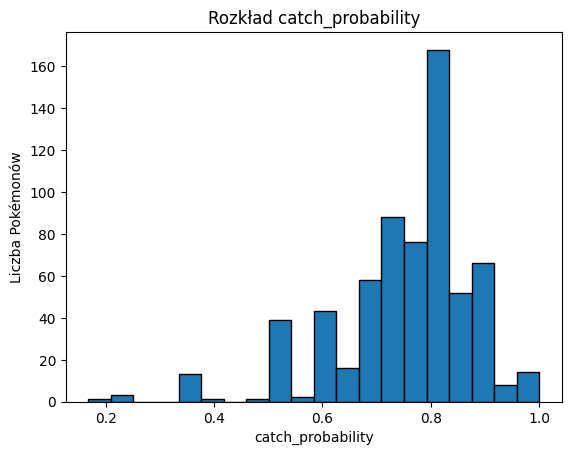

In [32]:
plt.hist(df["catch_probability"], bins=20, edgecolor="black")
plt.title("Rozkład catch_probability")
plt.xlabel("catch_probability")
plt.ylabel("Liczba Pokémonów")
plt.show()

Rozkład `catch_probability` pokazuje, jak bardzo różnią się Pokémony pod względem łącznej szansy złapania przed ucieczką. Ta zmienna zostanie następnie wykorzystana do utworzenia klas `easy` i `hard`.

In [33]:
df.loc[df["catch_probability"] == df["catch_probability"].min(),
    ["Name", "Capture_rate", "Escape_rate", "catch_probability"]]

,Name,Capture_rate,Escape_rate,catch_probability
467,Togekiss,0.01,0.05,0.168067


In [34]:
df.loc[df["catch_probability"] == df["catch_probability"].max(),
    ["Name", "Capture_rate", "Escape_rate", "catch_probability"]]

,Name,Capture_rate,Escape_rate,catch_probability
150,Mew,1.00,0.0,1.0
250,Celebi,1.00,0.0,1.0
384,Jirachi,1.00,0.0,1.0
479,Uxie,0.02,0.0,1.0
480,Mesprit,0.02,0.0,1.0
481,Azelf,0.02,0.0,1.0
488,Phione,0.02,0.0,1.0
489,Manaphy,0.02,0.0,1.0
490,Darkrai,0.02,0.0,1.0
491,Shaymin,0.02,0.0,1.0


In [35]:
median_prob = df["catch_probability"].median()

df["catch_difficulty"] = np.where(
    df["catch_probability"] >= median_prob,
    "easy",
    "hard"
)

print("Mediana catch_probability:", median_prob)
print("\nRozkład klas:")
print(df["catch_difficulty"].value_counts())
print("\nRozkład klas [%]:")
print((df["catch_difficulty"].value_counts(normalize=True) * 100).round(2))

Mediana catch_probability: 0.78125

Rozkład klas:
catch_difficulty
easy    368
hard    281
Name: count, dtype: int64

Rozkład klas [%]:
catch_difficulty
easy    56.7
hard    43.3
Name: proportion, dtype: float64


Na podstawie mediany `catch_probability` utworzono binarną zmienną celu `catch_difficulty`:

- `easy` — Pokémony z prawdopodobieństwem złapania równym lub większym od mediany,
- `hard` — Pokémony z prawdopodobieństwem złapania mniejszym od mediany.

Podział względem mediany pozwala uzyskać w miarę zrównoważone klasy.

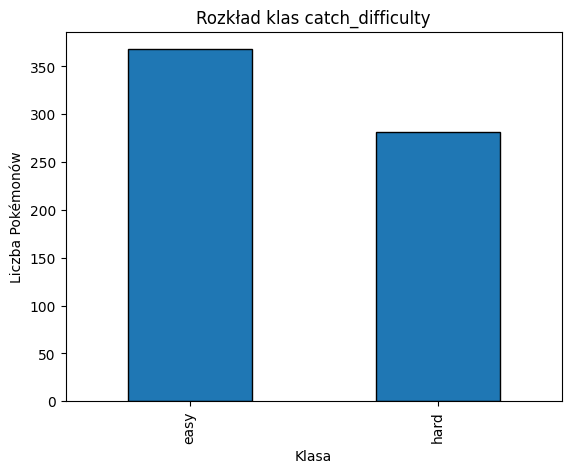

In [36]:
df["catch_difficulty"].value_counts().plot(kind="bar", edgecolor="black")

plt.title("Rozkład klas catch_difficulty")
plt.xlabel("Klasa")
plt.ylabel("Liczba Pokémonów")
plt.show()

Rozkład klas pokazuje, że problem klasyfikacyjny jest umiarkowanie zbalansowany. Jest to istotne przy późniejszej interpretacji metryk jakości modeli.

### Zależność cech od klasy trudności złapania

Poniżej sprawdzono, jak wybrane cechy Pokémonów różnią się pomiędzy klasami `easy` i `hard`. Analiza ta pozwala wstępnie ocenić, które zmienne mogą być przydatne w modelowaniu klasyfikacyjnym.

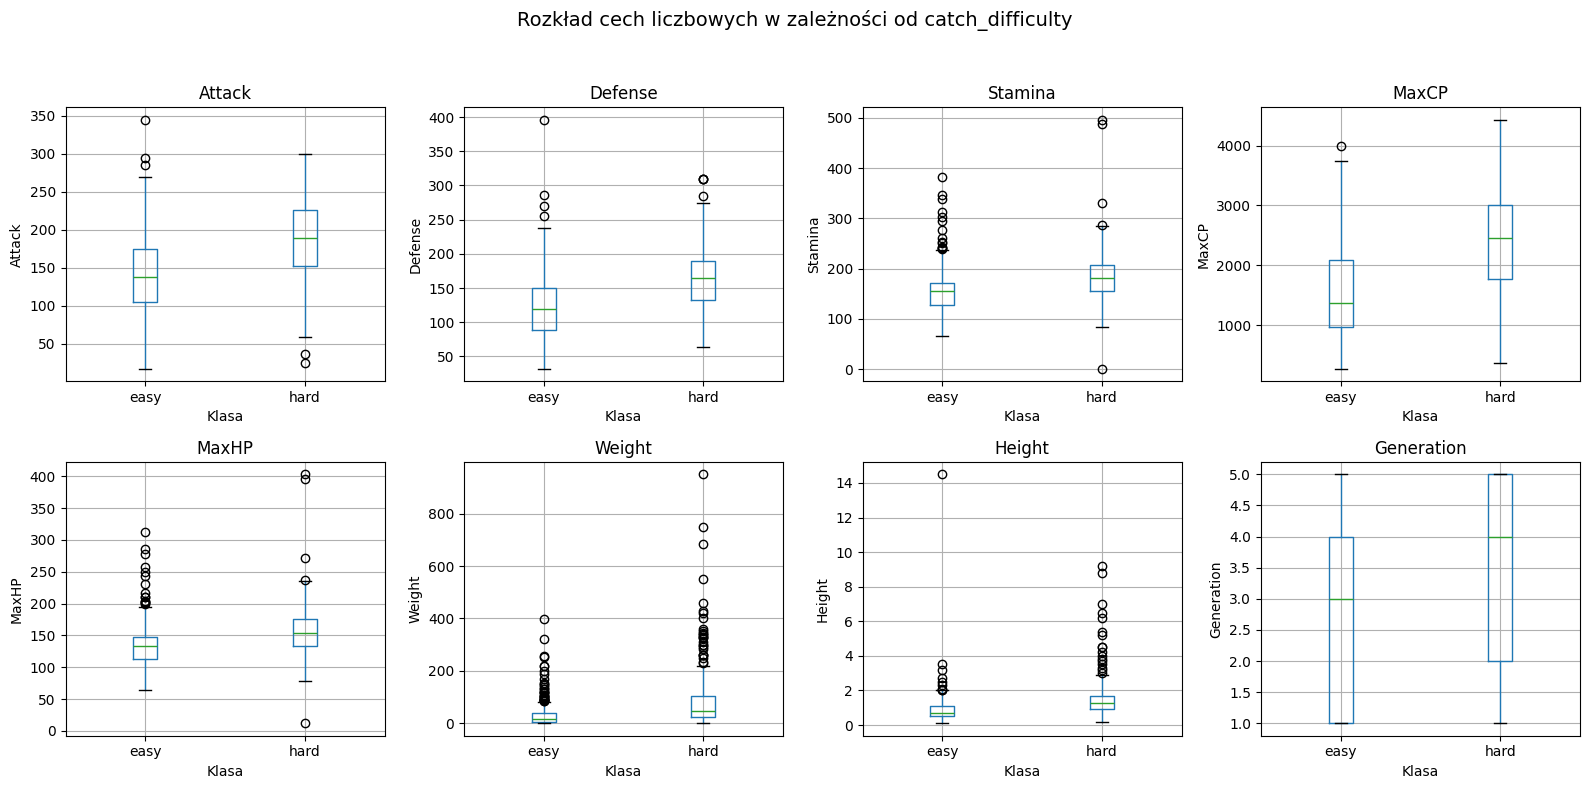

In [37]:
features_to_plot = [
    "Attack", "Defense", "Stamina", "MaxCP",
    "MaxHP", "Weight", "Height", "Generation"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    df.boxplot(
        column=feature,
        by="catch_difficulty",
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("Klasa")
    axes[i].set_ylabel(feature)

plt.suptitle("Rozkład cech liczbowych w zależności od catch_difficulty", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [38]:
median_by_class = df.groupby("catch_difficulty")[features_to_plot].median()

median_by_class

,Attack,Defense,Stamina,MaxCP,MaxHP,Weight,Height,Generation
catch_difficulty,,,,,,,,
easy,137.5,119.0,155.0,1369.0,134.0,18.0,0.7,3.0
hard,189.0,165.0,181.0,2461.0,154.0,48.7,1.3,4.0


W porównaniu median widać, że klasy `easy` i `hard` różnią się pod względem cech liczbowych. Pokémony z klasy `hard` mają zwykle wyższe wartości cech opisujących siłę i wytrzymałość, co jest zgodne z intuicją: silniejsze Pokémony są częściej trudniejsze do złapania. Różnice nie są jednak skrajnie duże, dlatego można oczekiwać, że klasyfikacja nie będzie całkowicie trywialna.

### Rozkład klas `easy`/`hard` według typu głównego

Dla zmiennej kategorycznej `Primary` sprawdzono, jak rozkładają się klasy `easy` i `hard` w obrębie poszczególnych typów Pokémonów. Ponieważ typy mają różną liczebność, oprócz liczby Pokémonów według typu pokazano również procentowy rozkład klas w każdym typie.

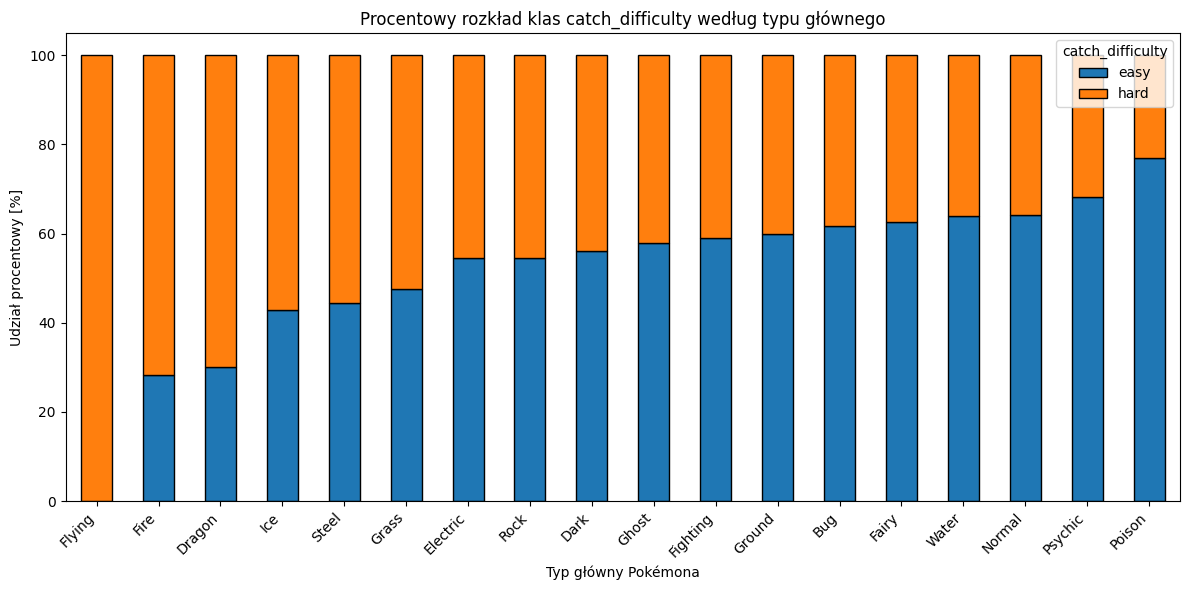

In [39]:
type_class_counts = pd.crosstab(
    df["Primary"],
    df["catch_difficulty"],
    normalize="index"
) * 100

type_class_counts = type_class_counts.sort_values(by="hard", ascending=False)

type_class_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    edgecolor="black"
)

plt.title("Procentowy rozkład klas catch_difficulty według typu głównego")
plt.xlabel("Typ główny Pokémona")
plt.ylabel("Udział procentowy [%]")
plt.xticks(rotation=45, ha="right")
plt.legend(title="catch_difficulty")

plt.tight_layout()
plt.show()

In [40]:
type_summary = pd.DataFrame({
    "liczba_pokemonow": df["Primary"].value_counts(),
    "procent_hard": type_class_counts["hard"]
})

type_summary = type_summary.sort_values(by="procent_hard", ascending=False)

type_summary

,liczba_pokemonow,procent_hard
Primary,,
Flying,1,100.000000
Fire,39,71.794872
Dragon,20,70.000000
Ice,21,57.142857
Steel,18,55.555556
Grass,61,52.459016
Electric,33,45.454545
Rock,33,45.454545
Dark,25,44.000000


Rozkład klas różni się między typami Pokémonów, jednak interpretacja tych różnic wymaga ostrożności, ponieważ niektóre typy są reprezentowane przez mniejszą liczbę obserwacji. Dlatego sam typ Pokémona nie powinien być traktowany jako jednoznaczny wyznacznik trudności złapania.

### Przygotowanie do modelowania

W tej części porównano pięć klasycznych modeli klasyfikacyjnych: perceptron, regresję logistyczną, kNN, SVM oraz drzewo decyzyjne.

Celem modelowania jest sprawdzenie, czy na podstawie cech opisujących Pokémona można przewidzieć klasę `catch_difficulty`, czyli czy Pokémon należy do grupy łatwiejszych (`easy`) czy trudniejszych (`hard`) do złapania.

Przed modelowaniem należy usunąć z cech wejściowych `Capture_rate`, `Escape_rate` oraz `catch_probability`, ponieważ zostały wykorzystane do utworzenia zmiennej celu. Pozostawienie ich w zbiorze cech prowadziłoby do przecieku danych, czyli sytuacji, w której model korzysta z informacji bezpośrednio związanej z odpowiedzią.

Należy usunąć również kolumny `Primary` i `Secondary`, ponieważ typy Pokémonów zostały już zakodowane metodą one-hot encoding. W ramce pozostają kolumny binarne zaczynające się od `Primary_` oraz `Secondary_`.

Usunięto również `Name` oraz `Pokedex`, ponieważ są to identyfikatory, a nie cechy opisujące właściwości Pokémona w sposób użyteczny dla modelu.

In [41]:
X = df.drop(columns=[
    "Name",
    "Pokedex",
    "Primary",
    "Secondary",
    "Capture_rate",
    "Escape_rate",
    "catch_probability",
    "catch_difficulty"
])

y = df["catch_difficulty"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Wybór wariantu cech

Przed finalnym trenowaniem modeli sprawdzono jeszcze, czy warto uwzględniać typy Pokémonów. W zbiorze typy zostały wcześniej zakodowane metodą one-hot encoding jako kolumny zaczynające się od `Primary_` oraz `Secondary_`. Ponieważ wcześniejsza analiza korelacji wskazywała, że pojedyncze typy mają słabą zależność z parametrami łapania, porównano dwa warianty danych: z kolumnami typów oraz bez tych kolumn.

Porównanie wariantów wykonano za pomocą 5-krotnej walidacji krzyżowej z metryką `f1_macro`. W dalszej części wykorzystano wariant danych, który dawał lepsze lub porównywalne wyniki dla większości modeli.

Do oceny modeli wykorzystano accuracy, balanced accuracy, precision, recall oraz F1-score. Szczególną uwagę zwrócono na `f1_macro` oraz `balanced_accuracy`, ponieważ uwzględniają one jakość klasyfikacji obu klas.

In [43]:
X_with_types = X.copy()

# kolumny odpowiadające typom Pokemonów
type_columns = [
    col for col in X_with_types.columns
    if col.startswith("Primary_") or col.startswith("Secondary_")
]

# wariant bez typów
X_no_types = X_with_types.drop(columns=type_columns)

cv_models = {
    "Perceptron": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Perceptron(max_iter=1000, random_state=42))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, random_state=42))
    ]),

    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in cv_models.items():
    scores_with_types = cross_val_score(
        model,
        X_with_types,
        y,
        cv=cv,
        scoring="f1_macro"
    )

    scores_no_types = cross_val_score(
        model,
        X_no_types,
        y,
        cv=cv,
        scoring="f1_macro"
    )

    cv_results.append({
        "model": model_name,
        "f1_macro_with_types_mean": scores_with_types.mean(),
        "f1_macro_with_types_std": scores_with_types.std(),
        "f1_macro_no_types_mean": scores_no_types.mean(),
        "f1_macro_no_types_std": scores_no_types.std(),
        "difference_no_types_minus_with_types": scores_no_types.mean() - scores_with_types.mean()
    })

cv_comparison_df = pd.DataFrame(cv_results)

cv_comparison_df = cv_comparison_df.sort_values(
    by="difference_no_types_minus_with_types",
    ascending=False
)

cv_comparison_df

,model,f1_macro_with_types_mean,f1_macro_with_types_std,f1_macro_no_types_mean,f1_macro_no_types_std,difference_no_types_minus_with_types
3,SVM,0.637339,0.049842,0.711725,0.057455,0.074386
2,kNN,0.621676,0.055986,0.687401,0.040665,0.065725
1,Logistic Regression,0.681019,0.043297,0.700408,0.043451,0.019389
4,Decision Tree,0.676134,0.051714,0.682929,0.047831,0.006795
0,Perceptron,0.610329,0.052792,0.585880,0.092325,-0.024448


Wyniki walidacji krzyżowej pokazują, że wariant bez kolumn opisujących typy Pokémonów osiąga średnio lepsze wyniki dla większości modeli. Największą poprawę zaobserwowano dla SVM oraz kNN, czyli modeli wrażliwych na strukturę przestrzeni cech. Może to wynikać z faktu, że one-hot encoding typów dodaje wiele binarnych kolumn, które nie niosą silnego sygnału, a jednocześnie zwiększają wymiarowość danych. Dla drzewa decyzyjnego różnica była niewielka, natomiast perceptron jako jedyny uzyskał lepszy wynik po pozostawieniu typów.

W dalszej części projektu wykorzystano wariant bez kolumn `Primary_...` i `Secondary_...`, ponieważ dawał on lepsze lub porównywalne wyniki dla większości analizowanych modeli.

In [44]:
X = X_no_types.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Trenowanie i ocena modeli podstawowych

Po wyborze finalnego zestawu cech wytrenowano pięć modeli klasyfikacyjnych. Modele wrażliwe na skalę cech, czyli perceptron, regresję logistyczną, kNN oraz SVM, trenowano na danych przeskalowanych za pomocą `StandardScaler`. Drzewo decyzyjne trenowano na danych nieskalowanych, ponieważ nie wymaga standaryzacji zmiennych.

In [45]:
models = {
    "Perceptron": {
        "model": Perceptron(max_iter=1000, random_state=42),
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    },

    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    },

    "kNN": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    },

    "SVM": {
        "model": SVC(kernel="rbf", C=1.0, random_state=42),
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(max_depth=4, random_state=42),
        "X_train": X_train,
        "X_test": X_test
    }
}

In [46]:
results = []
predictions = {}

for model_name, item in models.items():
    model = item["model"]
    X_tr = item["X_train"]
    X_te = item["X_test"]

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    predictions[model_name] = y_pred

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro")
    })

    print("\n" + "="*60)
    print(model_name)
    print("="*60)
    print(classification_report(y_test, y_pred))


Perceptron
              precision    recall  f1-score   support

        easy       0.69      0.55      0.62        74
        hard       0.54      0.68      0.60        56

    accuracy                           0.61       130
   macro avg       0.62      0.62      0.61       130
weighted avg       0.63      0.61      0.61       130


Logistic Regression
              precision    recall  f1-score   support

        easy       0.71      0.69      0.70        74
        hard       0.60      0.62      0.61        56

    accuracy                           0.66       130
   macro avg       0.66      0.66      0.66       130
weighted avg       0.66      0.66      0.66       130


kNN
              precision    recall  f1-score   support

        easy       0.72      0.68      0.70        74
        hard       0.61      0.66      0.63        56

    accuracy                           0.67       130
   macro avg       0.67      0.67      0.67       130
weighted avg       0.67      0.67   

In [47]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="f1_macro",
    ascending=False
)

results_df

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
3,SVM,0.692308,0.684122,0.685916,0.684122,0.684848
4,Decision Tree,0.684615,0.686052,0.682658,0.686052,0.682341
2,kNN,0.669231,0.668195,0.665598,0.668195,0.665890
1,Logistic Regression,0.661538,0.657095,0.655891,0.657095,0.656333
0,Perceptron,0.607692,0.616313,0.615063,0.616313,0.607483


Tabela przedstawia wyniki pięciu modeli klasyfikacyjnych na zbiorze testowym. Do porównania modeli wykorzystano kilka metryk, ponieważ samo accuracy może być mylące przy nierównym rozkładzie klas.

Szczególnie istotne są `f1_macro` oraz `balanced_accuracy`, ponieważ traktują klasy `easy` i `hard` w bardziej zrównoważony sposób. Dzięki temu można ocenić, czy model dobrze rozpoznaje obie klasy, a nie tylko częściej występującą klasę.

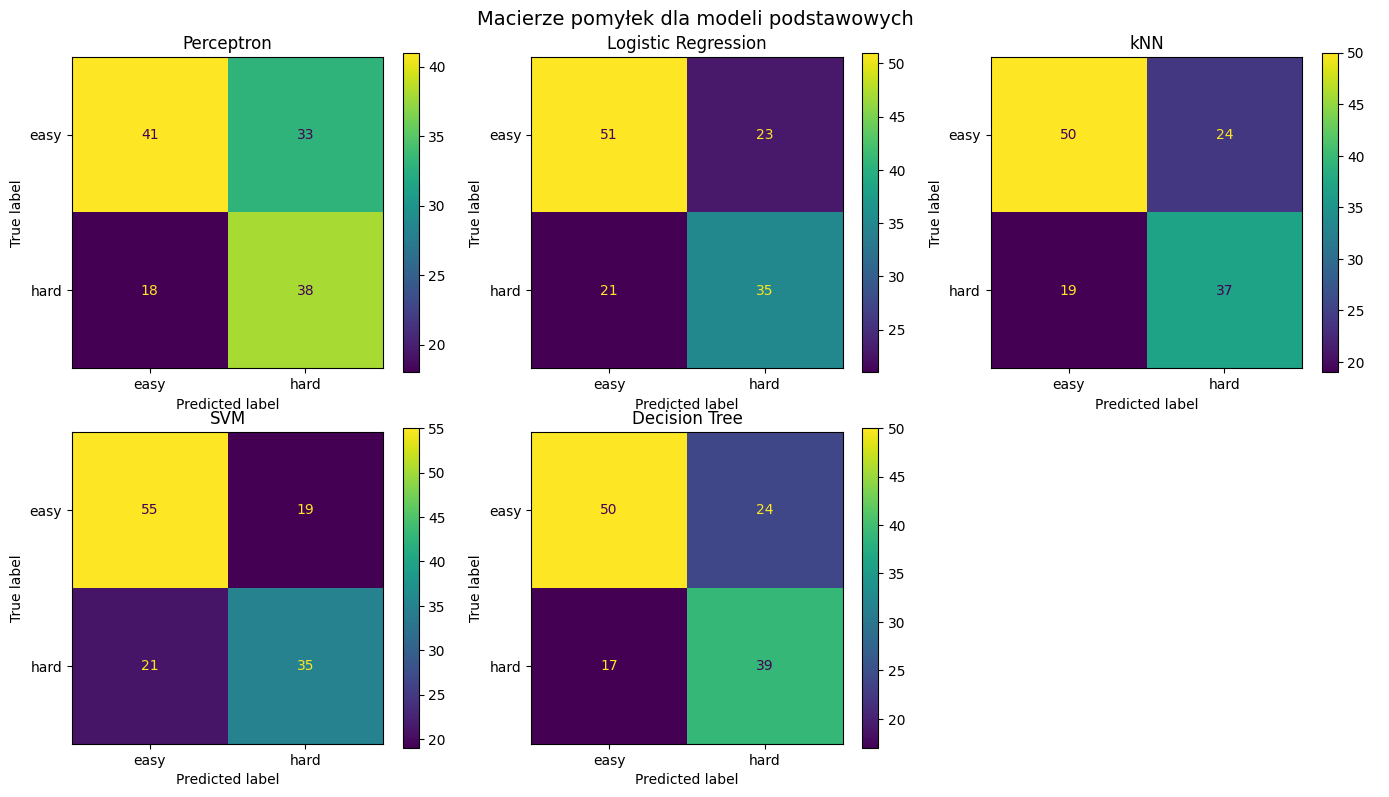

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes = axes.flatten()

for i, (model_name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=["easy", "hard"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["easy", "hard"]
    )

    disp.plot(ax=axes[i], colorbar=True)
    axes[i].set_title(model_name)

axes[-1].axis("off")

plt.suptitle("Macierze pomyłek dla modeli podstawowych", fontsize=14)
plt.tight_layout()
plt.show()



Wyniki pokazują, że problem klasyfikacyjny nie jest trywialny. Żaden model nie osiąga bardzo wysokiej skuteczności, co oznacza, że dostępne cechy tylko częściowo wyjaśniają trudność złapania Pokémona.

Macierze pomyłek pokazują, że modele różnią się sposobem popełniania błędów. SVM najlepiej rozpoznaje klasę `easy`, natomiast drzewo decyzyjne najlepiej radzi sobie z rozpoznawaniem klasy `hard`. Jest to istotne, ponieważ w tym projekcie ważne jest nie tylko ogólne accuracy, ale również poprawne wykrywanie Pokémonów trudniejszych do złapania.


Najgorzej spośród analizowanych modeli wypadł perceptron. Jego wynik `f1_macro` był najniższy, co wskazuje, że prosty liniowy model nie opisuje dobrze zależności między cechami Pokémonów a klasą trudności złapania.

Najlepszy wynik ogólny uzyskał model SVM, który osiągnął najwyższe wartości `accuracy` oraz `f1_macro`. Bardzo zbliżony wynik uzyskało drzewo decyzyjne, dlatego oba modele można uznać za najlepsze spośród modeli podstawowych.



### Analiza drzewa dycyzyjnego

Drzewo decyzyjne uzyskało najwyższą wartość `balanced_accuracy`, a na podstawie macierzy pomyłek najlepiej rozpoznawało klasę `hard`. Z tego względu do dalszej analizy wybrano drzewo decyzyjne. Wybór ten jest uzasadniony również interpretowalnością modelu - drzewo decyzyjne pozwala łatwiej przeanalizować, które cechy wpływają na klasyfikację Pokémona jako łatwego lub trudnego do złapania.

W tej części przeprowadzono dokładniejszą ocenę drzewa decyzyjnego z wykorzystaniem walidacji krzyżowej, krzywej uczenia, krzywej walidacyjnej oraz doboru hiperparametrów metodą Grid Search.

In [49]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tree_cv_scores = cross_val_score(
    tree_model,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("Wyniki f1_macro w kolejnych foldach:")
print(tree_cv_scores)

print("\nŚredni wynik f1_macro:")
print(tree_cv_scores.mean())

print("\nOdchylenie standardowe:")
print(tree_cv_scores.std())

Wyniki f1_macro w kolejnych foldach:
[0.73037037 0.67733929 0.61538462 0.64959569 0.74195308]

Średni wynik f1_macro:
0.6829286091223149

Odchylenie standardowe:
0.047831212414622584


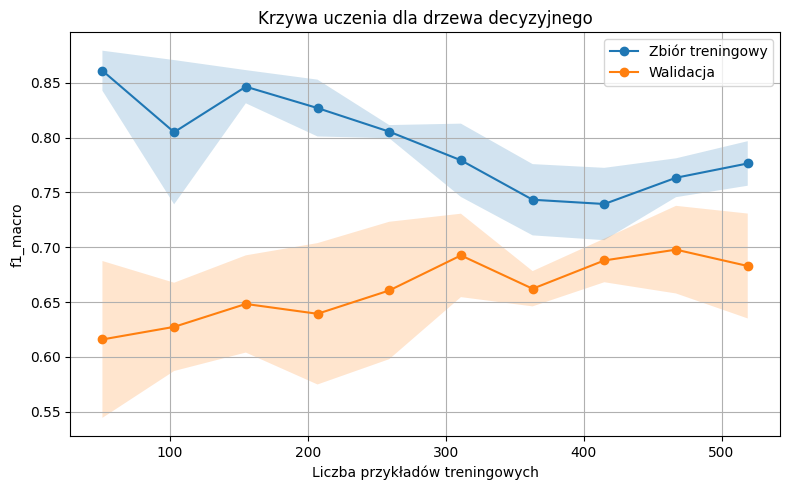

In [50]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=tree_model,
    X=X,
    y=y,
    cv=cv,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)

validation_scores_mean = validation_scores.mean(axis=1)
validation_scores_std = validation_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_scores_mean,
    marker="o",
    label="Zbiór treningowy"
)

plt.plot(
    train_sizes,
    validation_scores_mean,
    marker="o",
    label="Walidacja"
)

plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    validation_scores_mean - validation_scores_std,
    validation_scores_mean + validation_scores_std,
    alpha=0.2
)

plt.title("Krzywa uczenia dla drzewa decyzyjnego")
plt.xlabel("Liczba przykładów treningowych")
plt.ylabel("f1_macro")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Wyniki walidacji krzyżowej dla drzewa decyzyjnego są dość stabilne. Średnia wartość `f1_macro` wynosi około 0.683, a odchylenie standardowe około 0.048. Oznacza to, że jakość modelu nie zależy bardzo silnie od konkretnego podziału danych, chociaż wyniki w poszczególnych foldach nadal zauważalnie się różnią.

Krzywa uczenia pokazuje, że wynik na zbiorze treningowym jest wyraźnie wyższy niż wynik walidacyjny. Sugeruje to pewną tendencję modelu do przeuczenia, czyli lepszego dopasowania do danych treningowych niż do nowych obserwacji. Różnica między krzywymi zmniejsza się jednak wraz ze wzrostem liczby przykładów treningowych.

Wynik walidacyjny stopniowo rośnie wraz z dodawaniem danych treningowych, ale pod koniec zaczyna się stabilizować w okolicach 0.68–0.70. Oznacza to, że większa liczba danych mogłaby jeszcze nieznacznie poprawić jakość modelu, ale prawdopodobnie nie doprowadziłaby do bardzo dużego wzrostu skuteczności.

Na podstawie krzywej uczenia można uznać, że drzewo decyzyjne ma umiarkowaną zdolność generalizacji. Model nie jest całkowicie przeuczony, ale widoczna różnica między wynikiem treningowym i walidacyjnym wskazuje, że warto dobrać hiperparametry ograniczające złożoność drzewa, takie jak `max_depth`, `min_samples_split` lub `min_samples_leaf`.

Następnie sprawdzono wpływ parametru `max_depth` na jakość drzewa decyzyjnego. Parametr ten określa maksymalną głębokość drzewa, a więc kontroluje złożoność modelu.

Zbyt mała głębokość może prowadzić do niedouczenia modelu, ponieważ drzewo będzie zbyt proste. Zbyt duża głębokość może natomiast prowadzić do przeuczenia, czyli bardzo dobrego dopasowania do danych treningowych, ale gorszej jakości na danych walidacyjnych.

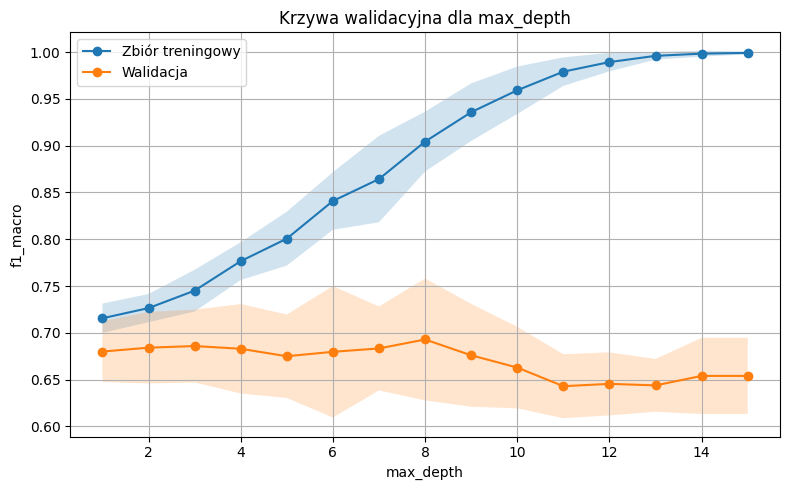

In [51]:
max_depth_range = range(1, 16)

train_scores, validation_scores = validation_curve(
    estimator=DecisionTreeClassifier(random_state=42),
    X=X,
    y=y,
    param_name="max_depth",
    param_range=max_depth_range,
    cv=cv,
    scoring="f1_macro"
)

train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)

validation_scores_mean = validation_scores.mean(axis=1)
validation_scores_std = validation_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    max_depth_range,
    train_scores_mean,
    marker="o",
    label="Zbiór treningowy"
)

plt.plot(
    max_depth_range,
    validation_scores_mean,
    marker="o",
    label="Walidacja"
)

plt.fill_between(
    max_depth_range,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    max_depth_range,
    validation_scores_mean - validation_scores_std,
    validation_scores_mean + validation_scores_std,
    alpha=0.2
)

plt.title("Krzywa walidacyjna dla max_depth")
plt.xlabel("max_depth")
plt.ylabel("f1_macro")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [52]:
validation_curve_df = pd.DataFrame({
    "max_depth": list(max_depth_range),
    "train_f1_macro_mean": train_scores_mean,
    "train_f1_macro_std": train_scores_std,
    "validation_f1_macro_mean": validation_scores_mean,
    "validation_f1_macro_std": validation_scores_std
})

validation_curve_df.sort_values(
    by="validation_f1_macro_mean",
    ascending=False
).head()

,max_depth,train_f1_macro_mean,train_f1_macro_std,validation_f1_macro_mean,validation_f1_macro_std
7,8,0.904378,0.031993,0.692869,0.065164
2,3,0.745080,0.022325,0.685847,0.038912
1,2,0.726427,0.015066,0.684117,0.038329
6,7,0.864370,0.046190,0.683293,0.044813
3,4,0.776591,0.020208,0.682929,0.047831


Krzywa walidacyjna pokazuje, że wraz ze wzrostem `max_depth` wynik na zbiorze treningowym systematycznie rośnie i dla dużych wartości zbliża się do 1.0. Oznacza to, że głębsze drzewo bardzo dobrze dopasowuje się do danych treningowych.

Wynik walidacyjny nie rośnie jednak w taki sam sposób. Najwyższą średnią wartość `f1_macro` uzyskano dla `max_depth = 8`, gdzie wynik walidacyjny wyniósł około 0.693. Dla większych głębokości wynik walidacyjny zaczyna spadać lub utrzymuje się na niższym poziomie, mimo że wynik treningowy nadal rośnie. Oznacza to, że zbyt głębokie drzewo zaczyna się przeuczać.

Na podstawie krzywej walidacyjnej widać, że złożoność drzewa ma duży wpływ na jakość modelu. Dlatego w kolejnym kroku zastosowano Grid Search, aby dobrać kilka hiperparametrów drzewa decyzyjnego jednocześnie.

Przeszukiwano wartości parametrów kontrolujących złożoność drzewa: `max_depth`, `min_samples_split` oraz `min_samples_leaf`. Celem było znalezienie modelu, który uzyska najwyższą średnią wartość `f1_macro` w walidacji krzyżowej.

In [53]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Najlepsze parametry:")
print(grid_search.best_params_)

print("\nNajlepszy wynik f1_macro w walidacji krzyżowej:")
print(grid_search.best_score_)

Najlepsze parametry:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Najlepszy wynik f1_macro w walidacji krzyżowej:
0.7212248121528809


In [54]:
grid_results_df = pd.DataFrame(grid_search.cv_results_)

grid_results_df = grid_results_df[[
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]]

grid_results_df.sort_values("rank_test_score").head(10)

,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score,rank_test_score
31,3,5,2,0.721225,0.047652,1
30,3,2,2,0.721225,0.047652,1
25,3,2,1,0.721225,0.047652,1
26,3,5,1,0.721225,0.047652,1
27,3,10,1,0.721225,0.047652,1
28,3,15,1,0.721225,0.047652,1
33,3,15,2,0.721225,0.047652,1
32,3,10,2,0.721225,0.047652,1
40,3,2,6,0.718414,0.044375,9
41,3,5,6,0.718414,0.044375,9


Grid Search wskazał jako najlepszy model drzewo decyzyjne o parametrach `max_depth = 3`, `min_samples_leaf = 1` oraz `min_samples_split = 2`. Najlepsza średnia wartość `f1_macro` w walidacji krzyżowej wyniosła około 0.721.

Wynik ten jest lepszy niż rezultat podstawowego drzewa decyzyjnego, co oznacza, że dobór hiperparametrów poprawił jakość modelu. Warto zauważyć, że najlepszy model jest stosunkowo prosty, ponieważ ma maksymalną głębokość równą 3. Jest to zgodne z wcześniejszą obserwacją, że zbyt głębokie drzewa mają tendencję do przeuczenia.

W tabeli wyników kilka kombinacji parametrów uzyskało taki sam najlepszy wynik. Oznacza to, że przy niewielkiej głębokości drzewa parametry `min_samples_split` i `min_samples_leaf` miały mniejsze znaczenie niż samo ograniczenie `max_depth`.

In [55]:
best_tree_model = grid_search.best_estimator_

y_pred_best_tree = best_tree_model.predict(X_test)

print(classification_report(y_test, y_pred_best_tree))

best_tree_results = {
    "accuracy": accuracy_score(y_test, y_pred_best_tree),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_best_tree),
    "precision_macro": precision_score(y_test, y_pred_best_tree, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_best_tree, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_best_tree, average="macro")
}

best_tree_results

              precision    recall  f1-score   support

        easy       0.73      0.73      0.73        74
        hard       0.64      0.64      0.64        56

    accuracy                           0.69       130
   macro avg       0.69      0.69      0.69       130
weighted avg       0.69      0.69      0.69       130



{'accuracy': 0.6923076923076923,
 'balanced_accuracy': np.float64(0.6862934362934363),
 'precision_macro': 0.6862934362934363,
 'recall_macro': 0.6862934362934363,
 'f1_macro': 0.6862934362934363}

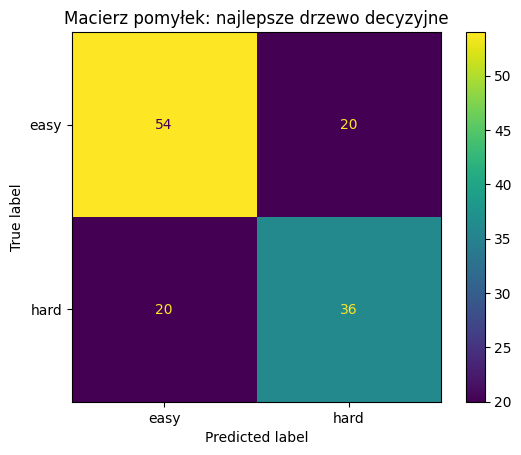

In [56]:
cm = confusion_matrix(
    y_test,
    y_pred_best_tree,
    labels=["easy", "hard"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["easy", "hard"]
)

disp.plot()
plt.title("Macierz pomyłek: najlepsze drzewo decyzyjne")
plt.show()

Najlepsze drzewo decyzyjne wybrane przez Grid Search uzyskało na zbiorze testowym `accuracy` równe około 0.692 oraz `f1_macro` równe około 0.686. Wynik ten jest nieznacznie lepszy od wyniku podstawowego drzewa decyzyjnego, co oznacza, że dobór hiperparametrów poprawił jakość modelu, ale nie doprowadził do dużej zmiany skuteczności.

Macierz pomyłek pokazuje, że model poprawnie sklasyfikował 54 Pokémony z klasy `easy` oraz 36 Pokémonów z klasy `hard`. Jednocześnie 20 Pokémonów z klasy `easy` zostało błędnie uznanych za `hard`, a 20 Pokémonów z klasy `hard` zostało błędnie uznanych za `easy`.

Wyniki dla obu klas są dość zbliżone, co widać również po podobnych wartościach precision, recall i F1-score dla klas `easy` oraz `hard`. Oznacza to, że model nie skupia się wyłącznie na częściej występującej klasie, lecz klasyfikuje obie klasy w stosunkowo zrównoważony sposób.

Mimo optymalizacji hiperparametrów skuteczność modelu pozostaje umiarkowana. Może to wynikać z faktu, że z cech wejściowych usunięto zmienne bezpośrednio związane z łapaniem, czyli `Capture_rate`, `Escape_rate`, aby uniknąć przecieku danych. Pozostałe cechy opisujące Pokémona pozwalają przewidywać trudność złapania tylko częściowo.

Na końcu przeanalizowano ważność cech w najlepszym drzewie decyzyjnym. Pozwala to sprawdzić, które zmienne miały największy wpływ na podział Pokémonów na klasy `easy` i `hard`.

Ważność cech w drzewie decyzyjnym oznacza, jak bardzo dana cecha przyczyniała się do zmniejszenia niejednorodności klas podczas budowy drzewa.

In [57]:
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_tree_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df

,feature,importance
7,MaxCP,0.710498
2,Defense,0.150574
5,Height,0.099409
4,Weight,0.039519
0,Stamina,0.000000
3,MaxHP,0.000000
1,Attack,0.000000
6,Legendary,0.000000
8,Generation,0.000000


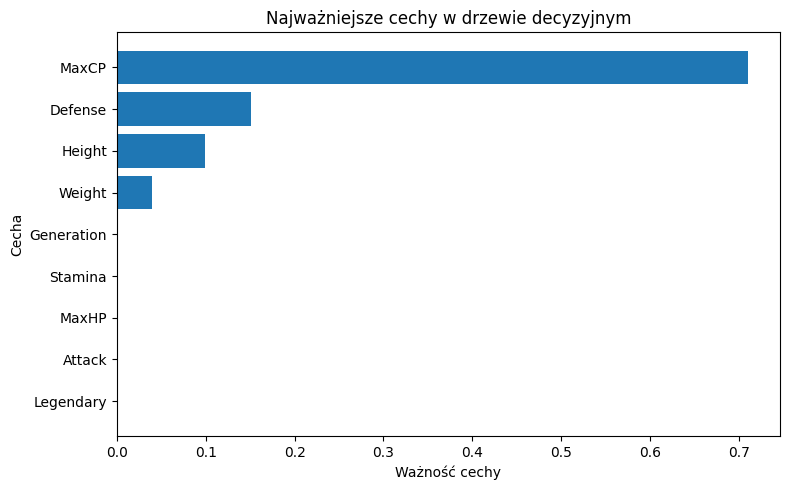

In [58]:
top_features = feature_importance_df.head(10).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Najważniejsze cechy w drzewie decyzyjnym")
plt.xlabel("Ważność cechy")
plt.ylabel("Cecha")

plt.tight_layout()
plt.show()

Analiza ważności cech pokazuje, że najlepsze drzewo decyzyjne opierało swoje decyzje przede wszystkim na zmiennej `MaxCP`. Jej ważność wyniosła około 0.71, co oznacza, że była zdecydowanie najistotniejszą cechą w modelu.

Drugą najważniejszą cechą była `Defense`, ale jej znaczenie było znacznie mniejsze. Mniejszy wpływ miały również `Height` oraz `Weight`. Pozostałe cechy, takie jak `Attack`, `Stamina`, `MaxHP`, `Legendary` i `Generation`, nie zostały wykorzystane przez najlepsze drzewo w podziałach lub ich wpływ był zerowy.

Taki wynik sugeruje, że model w największym stopniu wiąże trudność złapania Pokémona z jego ogólną siłą bojową, reprezentowaną przez `MaxCP`. Jest to zgodne z intuicją, ponieważ silniejsze Pokémony mogą częściej należeć do klasy trudniejszej do złapania. Jednocześnie należy pamiętać, że ważność cech w drzewie decyzyjnym zależy od konkretnej struktury modelu i nie oznacza bezpośredniej zależności przyczynowej.

Na podstawie tej analizy można uznać, że wybrany model jest dość prosty i łatwy do interpretacji, ponieważ większość decyzji opiera się na niewielkiej liczbie cech.

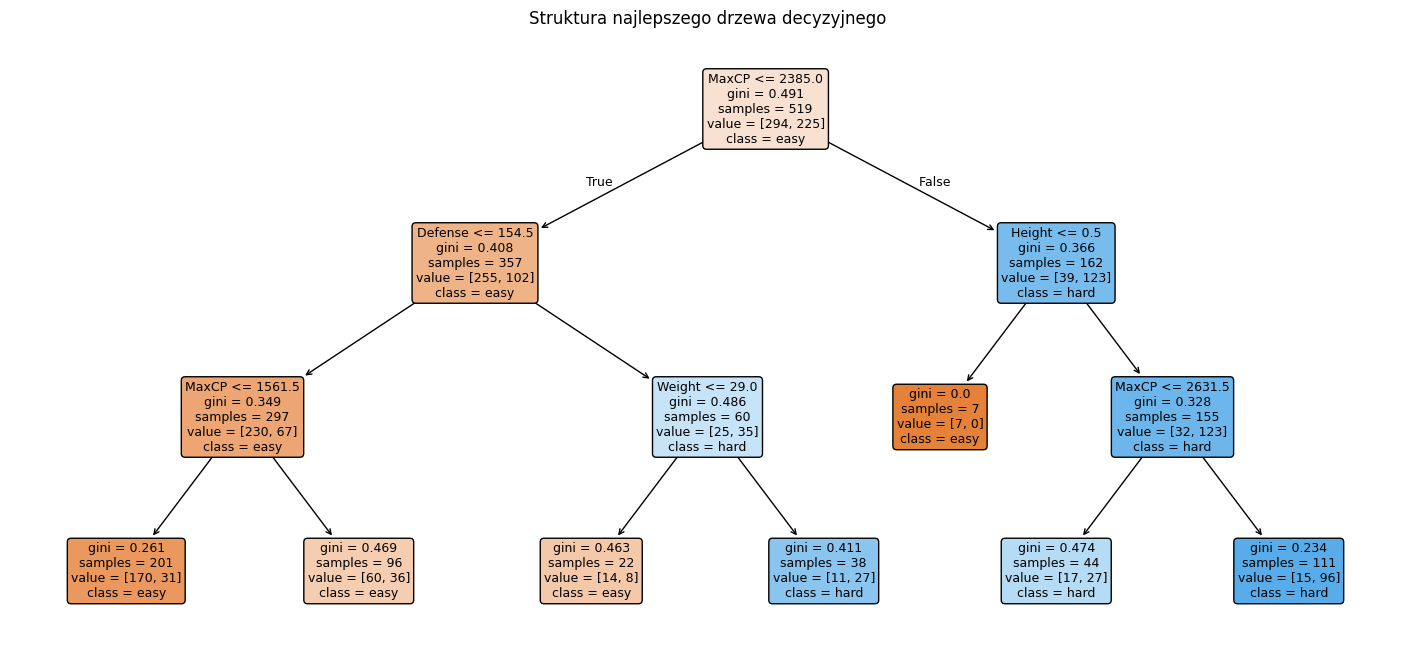

In [59]:
plt.figure(figsize=(18, 8))

plot_tree(
    best_tree_model,
    feature_names=X.columns,
    class_names=best_tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Struktura najlepszego drzewa decyzyjnego")
plt.show()

Struktura najlepszego drzewa decyzyjnego potwierdza wyniki analizy ważności cech. Pierwszy i najważniejszy podział został wykonany na podstawie zmiennej `MaxCP`. Pokémony z `MaxCP` mniejszym lub równym 2385 częściej trafiają do klasy `easy`, natomiast Pokémony z wyższym `MaxCP` częściej są klasyfikowane jako `hard`.

W lewej części drzewa, czyli dla Pokémonów o niższym `MaxCP`, model dodatkowo wykorzystuje cechy `Defense`, `Weight` oraz ponownie `MaxCP`. Większość liści w tej części drzewa ma klasę `easy`, co oznacza, że słabsze Pokémony są zwykle łatwiejsze do złapania.

W prawej części drzewa, czyli dla Pokémonów o wyższym `MaxCP`, dominują liście klasy `hard`. Model wykorzystuje tam cechy `Height` oraz ponownie `MaxCP`. Oznacza to, że Pokémony o większej ogólnej sile bojowej są częściej klasyfikowane jako trudniejsze do złapania.

Drzewo ma niewielką głębokość, dzięki czemu jest łatwe do interpretacji. Jednocześnie nie wszystkie liście są całkowicie jednorodne - w części z nich występują obserwacje obu klas. Pokazuje to, że model dobrze oddaje ogólną zależność między siłą Pokémona a trudnością złapania, ale nie rozdziela klas bezbłędnie.

Ogólnie struktura drzewa sugeruje, że `MaxCP` jest głównym czynnikiem używanym przez model, a pozostałe cechy pełnią funkcję pomocniczą przy bardziej szczegółowych podziałach.

### Podsumowanie i wnioski

Celem projektu było zbudowanie modelu klasyfikacyjnego przewidującego, czy Pokémon w Pokémon GO należy do klasy łatwiejszej (`easy`) czy trudniejszej (`hard`) do złapania. Zmienna celu została utworzona na podstawie uproszczonego prawdopodobieństwa złapania Pokémona przed jego ucieczką, obliczonego z wykorzystaniem `Capture_rate` oraz `Escape_rate`.

W ramach projektu porównano pięć modeli klasyfikacyjnych: perceptron, regresję logistyczną, kNN, SVM oraz drzewo decyzyjne. Przed finalnym modelowaniem sprawdzono również wpływ cech opisujących typy Pokémonów, zakodowanych metodą one-hot encoding. Walidacja krzyżowa pokazała, że wariant bez kolumn `Primary_...` i `Secondary_...` dawał lepsze lub porównywalne wyniki dla większości modeli, dlatego w dalszej analizie wykorzystano dane bez tych cech.

W porównaniu modeli podstawowych najlepszy wynik `f1_macro` uzyskał SVM, jednak drzewo decyzyjne osiągnęło bardzo zbliżony rezultat i lepiej rozpoznawało klasę `hard`. Z tego względu do dokładniejszej analizy wybrano drzewo decyzyjne. Dodatkowym argumentem za tym wyborem była interpretowalność modelu.

Dla drzewa decyzyjnego przeprowadzono walidację krzyżową, analizę krzywej uczenia, krzywej walidacyjnej oraz dobór hiperparametrów metodą Grid Search. Krzywa uczenia wskazała na umiarkowaną zdolność generalizacji modelu oraz pewną tendencję do przeuczenia. Krzywa walidacyjna pokazała, że zbyt duża głębokość drzewa zwiększa wynik na zbiorze treningowym, ale nie poprawia jakości na danych walidacyjnych.

Najlepsze drzewo decyzyjne po Grid Search uzyskało na zbiorze testowym `accuracy` około 0.692 oraz `f1_macro` około 0.686. Wyniki te oznaczają, że model potrafi częściowo przewidywać trudność złapania Pokémona, ale problem nie jest całkowicie prosty. Model nie osiąga bardzo wysokiej skuteczności, ponieważ najważniejsze zmienne bezpośrednio opisujące mechanikę łapania zostały celowo usunięte z cech wejściowych.

Analiza ważności cech oraz struktury drzewa pokazała, że najważniejszą cechą była `MaxCP`. Model w największym stopniu wykorzystywał więc ogólną siłę bojową Pokémona. Mniejsze znaczenie miały `Defense`, `Height` oraz `Weight`. Jest to zgodne z intuicją, ponieważ silniejsze Pokémony częściej mogą być trudniejsze do złapania.

### Ograniczenia i dalsze kierunki badań

Ograniczeniem projektu jest to, że wykorzystany zbiór danych opisuje głównie bazowe cechy gatunków Pokémonów, a nie cechy konkretnych spotkanych okazów. Oznacza to, że dla każdego gatunku dostępne są wartości takie jak bazowe statystyki, `Capture_rate` czy `Escape_rate`, ale nie ma informacji o tym, jak trudność złapania zmienia się między poszczególnymi osobnikami tego samego gatunku.

W rzeczywistej grze na złapanie Pokémona wpływają również cechy konkretnego spotkania i konkretnego okazu, takie jak poziom Pokémona, jego CP w momencie spotkania, użyty rodzaj Poké Balla, użycie jagód, jakość rzutu, curveball czy bonusy gracza. Tego typu dane nie były dostępne w wykorzystanym zbiorze, dlatego model opierał się wyłącznie na cechach bazowych przypisanych do gatunku.

Najciekawszym kierunkiem dalszych badań byłoby więc rozszerzenie analizy o dane zbierane na poziomie pojedynczych spotkań z Pokémonami, a nie tylko na poziomie gatunku. Na podstawie takich danych można byłoby sprawdzić, jak trudność złapania zmienia się w obrębie tego samego gatunku w zależności od cech konkretnego okazu i warunków próby złapania.

Mimo tych ograniczeń projekt pokazuje pełny proces budowy modelu klasyfikacyjnego: przygotowanie danych, utworzenie zmiennej celu, analizę eksploracyjną, porównanie modeli, walidację, dobór hiperparametrów oraz interpretację najlepszego modelu.